# Session 1

## Récupérer les données et les librairies

In [2]:
# Import necessary libraries
import pandas as pd  # to load the dataframe
from sklearn.preprocessing import StandardScaler  # to standardize the features
from sklearn.decomposition import PCA  # to apply PCA
import seaborn as sns  # to plot the heat maps
# Import data
import scipy.io

In [3]:
data_8 = scipy.io.loadmat('data/Rat8-20130713_proces_bin5.mat') # session 13 from rat 8 version not trunked
data_11 = scipy.io.loadmat('data/Rat11-20150327_proces_bin5.mat') # session 27 from rat 11 version not trunked

## Format des données

In [4]:
print("variables disponibles : ", data_8.keys())

variables disponibles :  dict_keys(['__header__', '__version__', '__globals__', 'cellexc', 'event', 'metadata', 'posit', 'ripl', 'spik'])


## Visualiation du parcours des rats

In [5]:
import matplotlib.pyplot as plt

In [6]:
posit = [data_8['posit'], data_11['posit']]

posit_prerun_8 = posit [0]['prerun'][0, 0]
posit_run_8 = posit [0]['run'][0, 0]
posit_postrun_8 = posit [0]['postrun'][0, 0]

posit_prerun_11 = posit [1]['prerun'][0, 0]
posit_run_11 = posit [1]['run'][0, 0]
posit_postrun_11 = posit [1]['postrun'][0, 0]

print("size postrun 8 : ", posit_postrun_8.shape)
print("size postrun 11 : ", posit_postrun_11.shape)

size postrun 8 :  (2, 5300)
size postrun 11 :  (2, 4458)


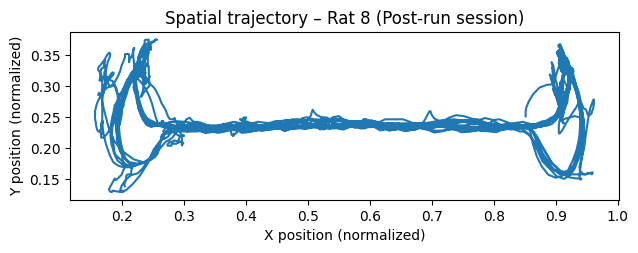

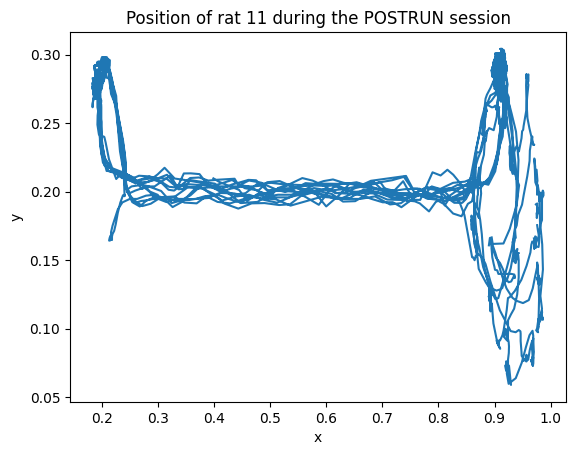

In [7]:
x = posit_postrun_8[0]
y = posit_postrun_8[1]

xb = posit_postrun_11[0]
yb = posit_postrun_11[1]

plt.plot(x, y)

plt.xlabel("X position (normalized)")
plt.ylabel("Y position (normalized)")
plt.title("Spatial trajectory – Rat 8 (Post-run session)")

plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig("Figures/spatial_trajectory_rat8_postrun.png")
plt.show()


plt.plot(xb, yb)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Position of rat 11 during the POSTRUN session")
plt.savefig("Figures/Position_Rat_11_POSTRUN.png")
plt.show()


# Récuperer les données qui nous intéressent 

Le couloir semble appartenir à l'intervalle [0.25, 0.85]. On veut donc tronquer la partie au extrémités pour avoir le temps plus exact que met le rat pour traverser le couloir et comparer les vitesses ce qui nous permettra plus tard de superposer les deux sessions des rats 8 et 11. Je propose donc de faire la chose suivante :

**Détecter les laps :**

- Lap gauche → droite : x passe de ≤ 0.25 à ≥ 0.85
- Lap droite → gauche : x passe de ≥ 0.85 à ≤ 0.25

**Pour chaque lap, extraire :**

- num_lap : 1, 2, 3, …
- direction : +1 si gauche → droite et -1 si droite → gauche
- temps_lap : durée entre le début et la fin du lap

In [8]:
import numpy as np

Fonctions pour créer les matrices laps pour chaque rats (qui stock les données qui non interessent)

In [9]:
# ============================================================
# Detect danger direction
# ============================================================

def get_danger_direction(event_run):
    """
    Determine danger direction from event_run.
    Returns +1 (left->right), -1 (right->left), or 0 if undefined.
    """
    event_run = np.squeeze(event_run)

    reward_idx = np.where((event_run == 2) | (event_run == 3))[0]
    directions = []

    for i in range(len(reward_idx) - 1):
        i0, i1 = reward_idx[i], reward_idx[i+1]
        r0 = event_run[i0]
        r1 = event_run[i1]

        # Check if danger occurred between the two rewards
        if np.any(event_run[i0:i1] == 1):
            if r0 == 3 and r1 == 2:
                directions.append(+1)  # left -> right
            elif r0 == 2 and r1 == 3:
                directions.append(-1)  # right -> left

    if len(directions) == 0:
        return 0

    return int(np.sign(np.mean(directions)))


# ============================================================
# Lap extraction
# ============================================================

def extract_laps(
    pos, event, dt_ms,
    left=0.25, right=0.85,
    cancel_on_backtrack=True,
    eps=1e-12
):
    x = np.asarray(pos[0], dtype=float)
    ev = np.asarray(event[0]).astype(int)
    n = len(x)
    assert len(ev) == n

    zone = np.full(n, "C", dtype="<U1")
    zone[x <= left + eps] = "L"
    zone[x >= right - eps] = "R"
    zone[np.isnan(x)] = "N"

    laps = []
    state = None
    start_idx = None

    for i in range(n):
        if zone[i] == "N":
            continue

        if state is None:
            if i > 0:
                j = i - 1
                while j >= 0 and zone[j] == "N":
                    j -= 1
                if j >= 0 and zone[j] == "L" and zone[i] == "C":
                    state = "LR"; start_idx = i
                elif j >= 0 and zone[j] == "R" and zone[i] == "C":
                    state = "RL"; start_idx = i

        else:
            if state == "LR":
                if cancel_on_backtrack and zone[i] == "L":
                    state = None; start_idx = None; continue

                if zone[i] == "R":
                    end_idx = i - 1
                    idx = np.arange(start_idx, end_idx + 1)
                    idx = idx[(~np.isnan(x[idx])) &
                              (x[idx] >= left - eps) &
                              (x[idx] <= right + eps)]

                    if idx.size >= 2:
                        laps.append({
                            "lap": len(laps) + 1,
                            "dir": +1,
                            "t_start": int(idx[0]),
                            "t_end": int(idx[-1]),
                            "duration_s": (idx[-1] - idx[0] + 1) * dt_ms / 1000.0,
                            "idx": idx,
                        })
                    state = None; start_idx = None

            elif state == "RL":
                if cancel_on_backtrack and zone[i] == "R":
                    state = None; start_idx = None; continue

                if zone[i] == "L":
                    end_idx = i - 1
                    idx = np.arange(start_idx, end_idx + 1)
                    idx = idx[(~np.isnan(x[idx])) &
                              (x[idx] >= left - eps) &
                              (x[idx] <= right + eps)]

                    if idx.size >= 2:
                        laps.append({
                            "lap": len(laps) + 1,
                            "dir": -1,
                            "t_start": int(idx[0]),
                            "t_end": int(idx[-1]),
                            "duration_s": (idx[-1] - idx[0] + 1) * dt_ms / 1000.0,
                            "idx": idx,
                        })
                    state = None; start_idx = None

    return laps


# ============================================================
# Add danger label to laps
# ============================================================

def label_laps_with_danger(laps, danger_dir):
    for lap in laps:
        lap["is_danger"] = (lap["dir"] == danger_dir)
    return laps

def split_by_direction(laps, field="duration_s"):
    left = np.array([lap[field] for lap in laps if lap["dir"] == -1], dtype=float)
    right = np.array([lap[field] for lap in laps if lap["dir"] == +1], dtype=float)
    return left, right

## Permet juste de récupérer la localisation du ddanger (air puff)

In [10]:
data_8b = scipy.io.loadmat('data/Rat8-20130713_proces_bin5_extract.mat') # session 13 from rat 8 version not trunked
data_11b = scipy.io.loadmat('data/Rat11-20150327_proces_bin5_extract.mat') # session 27 from rat 11 version not trunked

pos_puff_8 = data_8b['pos_puff']
pos_puff_11 = data_11b['pos_puff']

## Plot des Laps

In [11]:
event = [data_8['event'], data_11['event']]

event_run_8 = event [0]['postrun'][0, 0]
event_run_11 = event [1]['postrun'][0, 0]

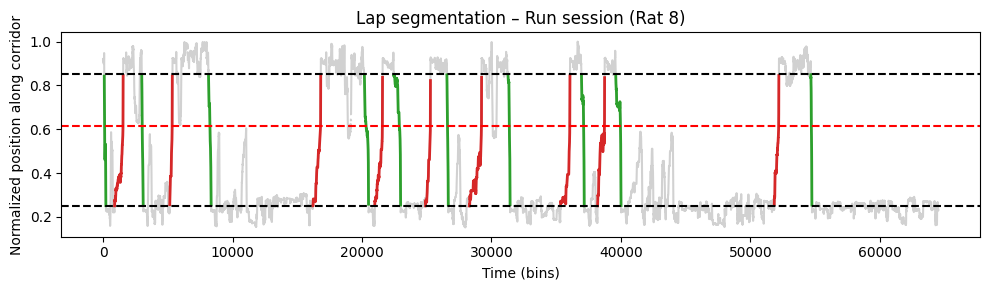

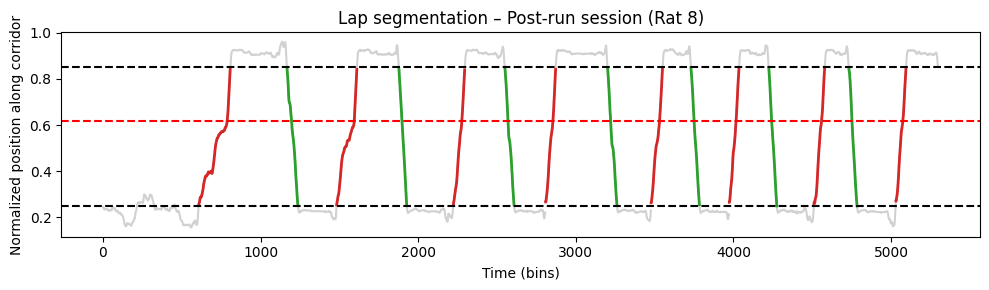

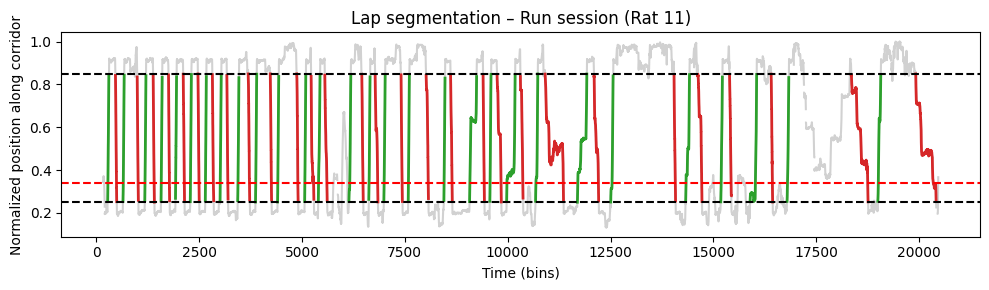

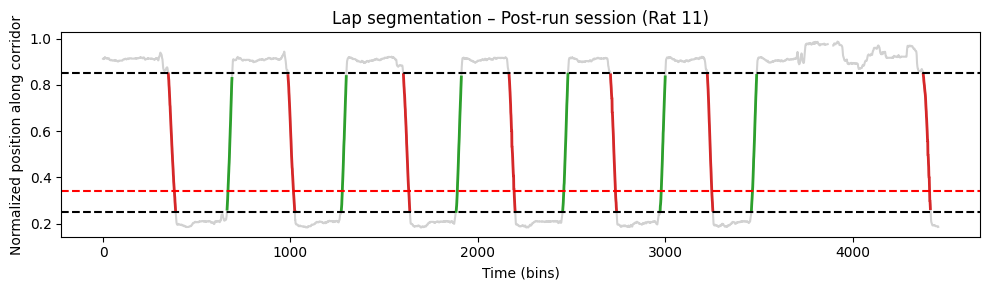

In [12]:
# ============================================================
# Plot helper
# ============================================================

def plot_laps_with_danger(pos, laps, title, left=0.25, right=0.85, puff=None):
    x = pos[0]

    plt.figure(figsize=(10,3))
    plt.plot(x, color="0.7", alpha=0.6)

    for lap in laps:
        c = "tab:red" if lap["is_danger"] else "tab:green"
        plt.plot(lap["idx"], x[lap["idx"]], lw=2, color=c)

    plt.axhline(left, color='black', ls='--')
    plt.axhline(right, color='black', ls='--')

    if puff is not None:
        plt.axhline(puff, color='red', ls='--')

    plt.xlabel("Time (bins)")
    plt.ylabel("Normalized position along corridor")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# ============================================================
# MAIN PIPELINE
# ============================================================

dt = 50  # ms per bin

# --- RAT 8 ---
event_run_8 = event[0]['run'][0, 0]
event_postrun_8 = event[0]['postrun'][0, 0]

danger_8 = get_danger_direction(event_run_8)

laps_run_8 = extract_laps(posit_run_8, event_run_8, dt)
laps_postrun_8 = extract_laps(posit_postrun_8, event_postrun_8, dt)

laps_run_8 = label_laps_with_danger(laps_run_8, danger_8)
laps_postrun_8 = label_laps_with_danger(laps_postrun_8, danger_8)

plot_laps_with_danger(
    posit_run_8, laps_run_8,
    "Lap segmentation – Run session (Rat 8)",
    puff=pos_puff_8
)

plot_laps_with_danger(
    posit_postrun_8, laps_postrun_8,
    "Lap segmentation – Post-run session (Rat 8)",
    puff=pos_puff_8
)


# --- RAT 11 ---
event_run_11 = event[1]['run'][0, 0]
event_postrun_11 = event[1]['postrun'][0, 0]

danger_11 = get_danger_direction(event_run_11)

laps_run_11 = extract_laps(posit_run_11, event_run_11, dt)
laps_postrun_11 = extract_laps(posit_postrun_11, event_postrun_11, dt)

laps_run_11 = label_laps_with_danger(laps_run_11, danger_11)
laps_postrun_11 = label_laps_with_danger(laps_postrun_11, danger_11)

plot_laps_with_danger(
    posit_run_11, laps_run_11,
    "Lap segmentation – Run session (Rat 11)",
    puff=pos_puff_11
)

plot_laps_with_danger(
    posit_postrun_11, laps_postrun_11,
    "Lap segmentation – Post-run session (Rat 11)",
    puff=pos_puff_11
)


## run ce code pour faire les plots pour la POSTRUN session

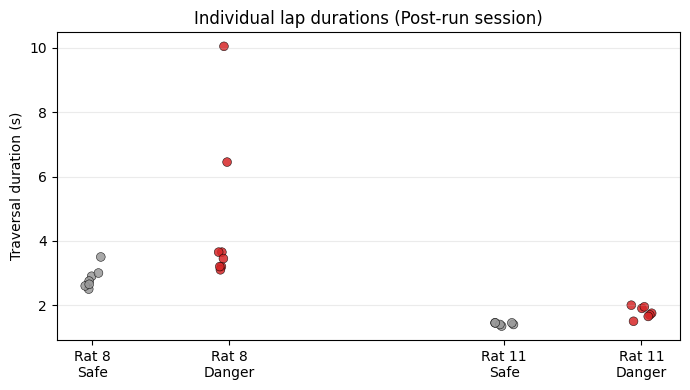

In [13]:
# ===============================
# Data
# ===============================

l1_neg, l1_pos = split_by_direction(laps_postrun_8)
l2_neg, l2_pos = split_by_direction(laps_postrun_11)

# On travaille en secondes (plus lisible)
means = [
    np.mean(l1_neg), np.mean(l1_pos),
    np.mean(l2_neg), np.mean(l2_pos),
]

stds = [
    np.std(l1_neg), np.std(l1_pos),
    np.std(l2_neg), np.std(l2_pos),
]

x = np.array([0, 1, 3, 4])

labels = [
    "Rat 8\nSafe",
    "Rat 8\nDanger",
    "Rat 11\nSafe",
    "Rat 11\nDanger"
]

def laps_to_points(laps, rat_id, danger_dir):
    xs, ys, colors = [], [], []

    base = 0 if rat_id == 8 else 3

    for lap in laps:
        direction = lap['dir']
        duration = lap['duration_s']

        is_danger = (direction == danger_dir)

        x = base + (1 if is_danger else 0)
        color = "tab:red" if is_danger else "0.6"

        xs.append(x)
        ys.append(duration)
        colors.append(color)

    return np.array(xs), np.array(ys), colors


x8, y8, c8 = laps_to_points(laps_postrun_8, 8, danger_8)
x11, y11, c11 = laps_to_points(laps_postrun_11, 11, danger_11)

# Jitter
jitter = 0.08

x8 = np.array(x8) + np.random.uniform(-jitter, jitter, len(x8))
x11 = np.array(x11) + np.random.uniform(-jitter, jitter, len(x11))

# ===============================
# Plot
# ===============================

plt.figure(figsize=(7,4))

plt.scatter(x8, y8, c=c8, s=40, edgecolor='black', linewidth=0.4, alpha=0.85)
plt.scatter(x11, y11, c=c11, s=40, edgecolor='black', linewidth=0.4, alpha=0.85)

plt.xticks(
    [0, 1, 3, 4],
    ["Rat 8\nSafe", "Rat 8\nDanger",
     "Rat 11\nSafe", "Rat 11\nDanger"]
)

plt.ylabel("Traversal duration (s)")
plt.title("Individual lap durations (Post-run session)")

plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig("Figures/LapDuration_points_POSTRUN.png", dpi=300)
plt.show()


## run ce code pour faire les plots pour la RUN session

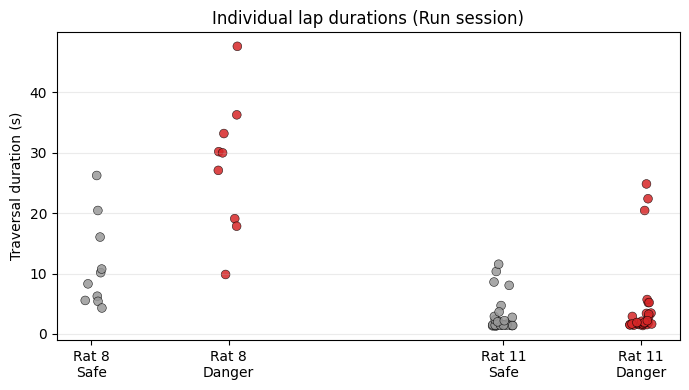

In [14]:
# ===============================
# Data
# ===============================

l1_neg, l1_pos = split_by_direction(laps_run_8)
l2_neg, l2_pos = split_by_direction(laps_run_11)

# On travaille en secondes (plus lisible)
means = [
    np.mean(l1_neg), np.mean(l1_pos),
    np.mean(l2_neg), np.mean(l2_pos),
]

stds = [
    np.std(l1_neg), np.std(l1_pos),
    np.std(l2_neg), np.std(l2_pos),
]

x = np.array([0, 1, 3, 4])

labels = [
    "Rat 8\nSafe",
    "Rat 8\nDanger",
    "Rat 11\nSafe",
    "Rat 11\nDanger"
]

def laps_to_points(laps, rat_id, danger_dir):
    xs, ys, colors = [], [], []

    base = 0 if rat_id == 8 else 3

    for lap in laps:
        direction = lap['dir']
        duration = lap['duration_s']

        is_danger = (direction == danger_dir)

        x = base + (1 if is_danger else 0)
        color = "tab:red" if is_danger else "0.6"

        xs.append(x)
        ys.append(duration)
        colors.append(color)

    return np.array(xs), np.array(ys), colors


x8, y8, c8 = laps_to_points(laps_run_8, 8, danger_8)
x11, y11, c11 = laps_to_points(laps_run_11, 11, danger_11)

# Jitter
jitter = 0.08

x8 = np.array(x8) + np.random.uniform(-jitter, jitter, len(x8))
x11 = np.array(x11) + np.random.uniform(-jitter, jitter, len(x11))

# ===============================
# Plot
# ===============================

plt.figure(figsize=(7,4))

plt.scatter(x8, y8, c=c8, s=40, edgecolor='black', linewidth=0.4, alpha=0.85)
plt.scatter(x11, y11, c=c11, s=40, edgecolor='black', linewidth=0.4, alpha=0.85)

plt.xticks(
    [0, 1, 3, 4],
    ["Rat 8\nSafe", "Rat 8\nDanger",
     "Rat 11\nSafe", "Rat 11\nDanger"]
)

plt.ylabel("Traversal duration (s)")
plt.title("Individual lap durations (Run session)")

plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig("Figures/LapDuration_points_RUN.png", dpi=300)
plt.show()


# Même chose avec les .extract (-20, +20 autour de la danger zone)

In [15]:
print("variables disponibles : ", data_8b.keys())

variables disponibles :  dict_keys(['__header__', '__version__', '__globals__', 'cellexc', 'event', 'lap_danger', 'lap_safe', 'length_track', 'metadata', 'pos_puff', 'pos_tot_postrun', 'pos_tot_prerun', 'pos_tot_run', 'posit', 'puff_dir', 'ripl', 'spk_extract_danger', 'spk_extract_safe', 'tbin', 'zone_postrun', 'zone_prerun', 'zone_run'])


# Essais avec le fichier .extract

pos_run shape: (64503,)
lap_danger min/max: 178 52186


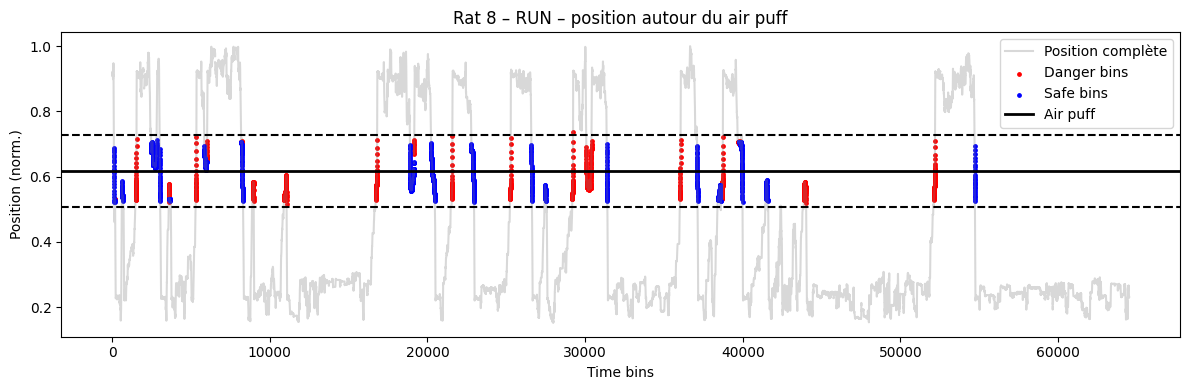

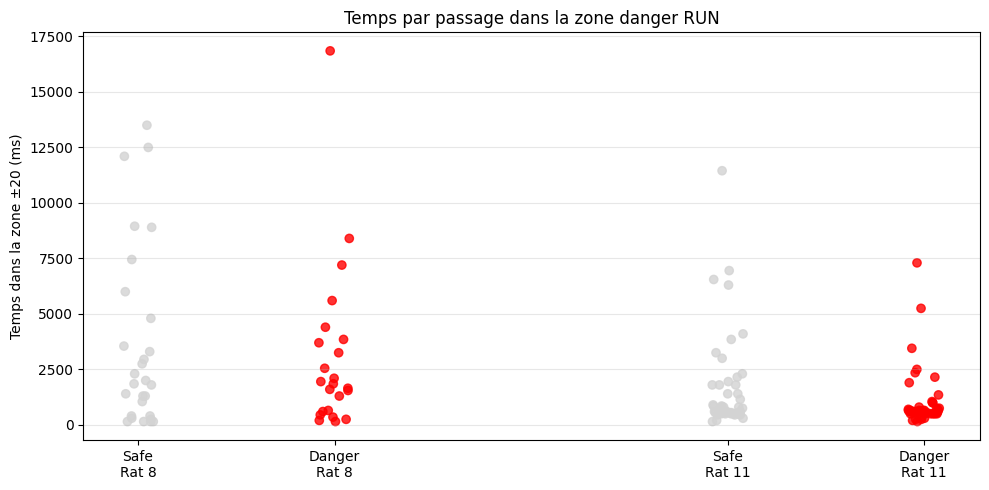

In [16]:
# =========================
# PARAMÈTRES
# =========================
dt = data_8b['tbin'][0][0]
track_length = data_8b['length_track'][0][0]

zone_cm = 20
zone_norm = zone_cm / track_length

# =========================
# DONNÉES
# =========================
pos_run = data_8b['posit']['run'][0,0][0]
pos_puff = data_8b['pos_puff'][0][0]

lap_danger = data_8b['lap_danger']['run'][0,0].ravel()
lap_safe   = data_8b['lap_safe']['run'][0,0].ravel()

print("pos_run shape:", pos_run.shape)
print("lap_danger min/max:", lap_danger.min(), lap_danger.max())

# =========================
# POSITION DANS LA ZONE
# =========================
pos_danger = pos_run[lap_danger]
pos_safe   = pos_run[lap_safe]

# =========================
# PLOT
# =========================
plt.figure(figsize=(12,4))
plt.plot(pos_run, color='gray', alpha=0.3, label='Position complète')

plt.scatter(lap_danger, pos_danger, s=6, color='red', label='Danger bins')
plt.scatter(lap_safe, pos_safe, s=6, color='blue', label='Safe bins')

plt.axhline(pos_puff, color='black', lw=2, label='Air puff')
plt.axhline(pos_puff + zone_norm, color='black', ls='--')
plt.axhline(pos_puff - zone_norm, color='black', ls='--')

plt.xlabel('Time bins')
plt.ylabel('Position (norm.)')
plt.title('Rat 8 – RUN – position autour du air puff')
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# PARAMÈTRES
# =========================
dt = 50  # ms par bin
jitter = 0.08

# =========================
# UTILS
# =========================
def split_contiguous(indices):
    """Découpe un vecteur de bins en segments contigus"""
    indices = np.asarray(indices).astype(int)
    indices = np.sort(indices)
    cuts = np.where(np.diff(indices) > 1)[0] + 1
    return np.split(indices, cuts)


def zone_laps_from_bins(lap_bins, dt, direction):
    """Transforme des bins en laps zone avec durée"""
    laps = []
    segments = split_contiguous(lap_bins)

    for seg in segments:
        if len(seg) < 3:   # sécurité anti bruit
            continue

        laps.append({
            'duration': len(seg) * dt,
            'dir': direction
        })

    return laps


def laps_to_points(laps, rat_id, danger_dir):
    xs, ys, colors = [], [], []

    for lap in laps:
        direction = lap['dir']
        time = lap['duration']

        base_x = 0 if rat_id == 8 else 3

        if direction == danger_dir:
            x = base_x + 1
            color = 'red'
        else:
            x = base_x
            color = 'lightgray'

        xs.append(x)
        ys.append(time)
        colors.append(color)

    return np.array(xs), np.array(ys), colors


# =========================
# RAT 8 — POSTRUN
# =========================
lap_danger_8 = data_8b['lap_danger']['run'][0,0][0]
lap_safe_8   = data_8b['lap_safe']['run'][0,0][0]

laps_8 = []
laps_8 += zone_laps_from_bins(lap_danger_8, dt, direction=pos_puff_8)
laps_8 += zone_laps_from_bins(lap_safe_8,   dt, direction=-pos_puff_8)


# =========================
# RAT 11 — POSTRUN
# =========================
lap_danger_11 = data_11b['lap_danger']['run'][0,0][0]
lap_safe_11   = data_11b['lap_safe']['run'][0,0][0]

laps_11 = []
laps_11 += zone_laps_from_bins(lap_danger_11, dt, direction=pos_puff_11)
laps_11 += zone_laps_from_bins(lap_safe_11,   dt, direction=-pos_puff_11)

# =========================
# PLOT
# =========================
x8, y8, c8 = laps_to_points(laps_8, rat_id=8, danger_dir=pos_puff_8)
x11, y11, c11 = laps_to_points(laps_11, rat_id=11, danger_dir=pos_puff_11)

x8 = x8 + np.random.uniform(-jitter, jitter, len(x8))
x11 = x11 + np.random.uniform(-jitter, jitter, len(x11))

plt.figure(figsize=(10,5))
plt.scatter(x8, y8, c=c8, alpha=0.8)
plt.scatter(x11, y11, c=c11, alpha=0.8)

plt.xticks(
    [0, 1, 3, 4],
    ['Safe\nRat 8', 'Danger\nRat 8', 'Safe\nRat 11', 'Danger\nRat 11']
)

plt.ylabel('Temps dans la zone ±20 (ms)')
plt.title('Temps par passage dans la zone danger RUN')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Mon extraction des dangers Zones

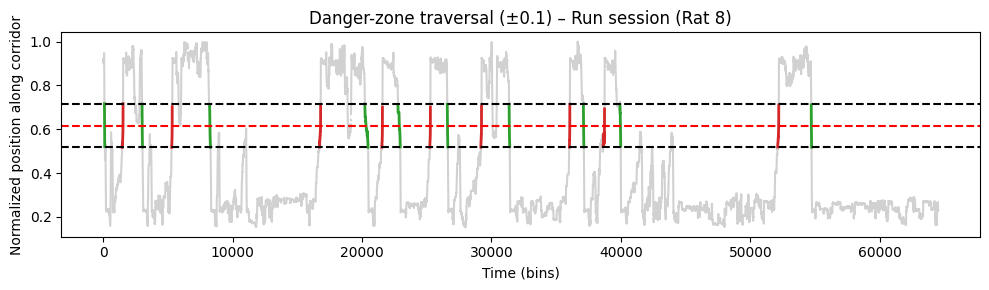

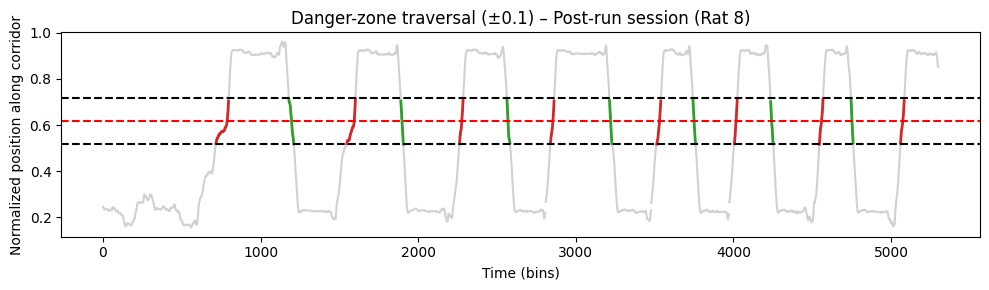

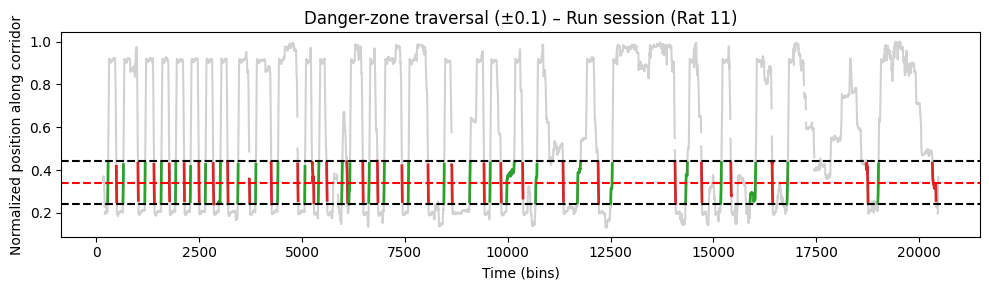

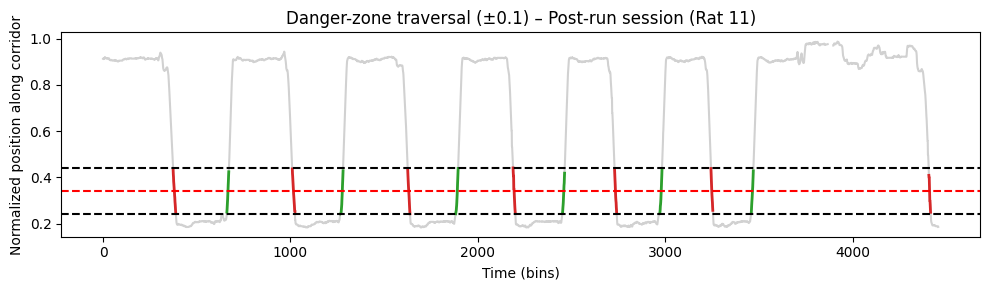

In [17]:
dt = 50  # ms per bin


# ============================================================
# Helper functions
# ============================================================

def get_danger_direction(event_run):
    event_run = np.squeeze(event_run)
    reward_idx = np.where((event_run == 2) | (event_run == 3))[0]
    directions = []

    for i in range(len(reward_idx) - 1):
        i0, i1 = reward_idx[i], reward_idx[i+1]
        r0 = event_run[i0]
        r1 = event_run[i1]

        if np.any(event_run[i0:i1] == 1):
            if r0 == 3 and r1 == 2:
                directions.append(+1)
            elif r0 == 2 and r1 == 3:
                directions.append(-1)

    if len(directions) == 0:
        return 0

    return int(np.sign(np.mean(directions)))


def label_laps_with_danger(laps, danger_dir):
    for lap in laps:
        lap["is_danger"] = (lap["dir"] == danger_dir)
    return laps


def plot_laps(pos, laps, left, right, puff, title):
    x = pos[0]

    plt.figure(figsize=(10,3))
    plt.plot(x, color="0.7", alpha=0.6)

    for lap in laps:
        c = "tab:red" if lap["is_danger"] else "tab:green"
        plt.plot(lap["idx"], x[lap["idx"]], lw=2, color=c)

    plt.axhline(left, color='black', ls='--')
    plt.axhline(right, color='black', ls='--')
    plt.axhline(puff, color='red', ls='--')

    plt.xlabel("Time (bins)")
    plt.ylabel("Normalized position along corridor")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# ============================================================
# RAT 8
# ============================================================

event_run_8 = event[0]['run'][0, 0]
event_postrun_8 = event[0]['postrun'][0, 0]

danger_8 = get_danger_direction(event_run_8)

extract_right = pos_puff_8[0][0] + 0.1
extract_left  = pos_puff_8[0][0] - 0.1

laps_run_8 = extract_laps(
    posit_run_8, event_run_8, dt,
    left=extract_left, right=extract_right
)

laps_postrun_8 = extract_laps(
    posit_postrun_8, event_postrun_8, dt,
    left=extract_left, right=extract_right
)

laps_run_8 = label_laps_with_danger(laps_run_8, danger_8)
laps_postrun_8 = label_laps_with_danger(laps_postrun_8, danger_8)

plot_laps(
    posit_run_8, laps_run_8,
    extract_left, extract_right, pos_puff_8,
    "Danger-zone traversal (±0.1) – Run session (Rat 8)"
)

plot_laps(
    posit_postrun_8, laps_postrun_8,
    extract_left, extract_right, pos_puff_8,
    "Danger-zone traversal (±0.1) – Post-run session (Rat 8)"
)


# ============================================================
# RAT 11
# ============================================================

event_run_11 = event[1]['run'][0, 0]
event_postrun_11 = event[1]['postrun'][0, 0]

danger_11 = get_danger_direction(event_run_11)

extract_right = pos_puff_11[0][0] + 0.1
extract_left  = pos_puff_11[0][0] - 0.1

laps_run_11 = extract_laps(
    posit_run_11, event_run_11, dt,
    left=extract_left, right=extract_right
)

laps_postrun_11 = extract_laps(
    posit_postrun_11, event_postrun_11, dt,
    left=extract_left, right=extract_right
)

laps_run_11 = label_laps_with_danger(laps_run_11, danger_11)
laps_postrun_11 = label_laps_with_danger(laps_postrun_11, danger_11)

plot_laps(
    posit_run_11, laps_run_11,
    extract_left, extract_right, pos_puff_11,
    "Danger-zone traversal (±0.1) – Run session (Rat 11)"
)

plot_laps(
    posit_postrun_11, laps_postrun_11,
    extract_left, extract_right, pos_puff_11,
    "Danger-zone traversal (±0.1) – Post-run session (Rat 11)"
)

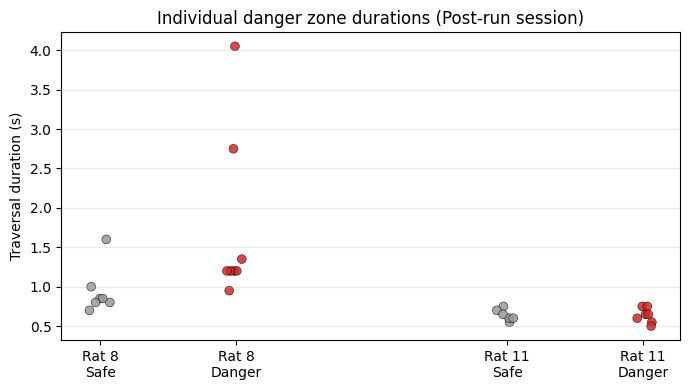

In [ ]:
# ===============================
# Data
# ===============================

l1_neg, l1_pos = split_by_direction(laps_postrun_8)
l2_neg, l2_pos = split_by_direction(laps_postrun_11)

# On travaille en secondes (plus lisible)
means = [
    np.mean(l1_neg), np.mean(l1_pos),
    np.mean(l2_neg), np.mean(l2_pos),
]

stds = [
    np.std(l1_neg), np.std(l1_pos),
    np.std(l2_neg), np.std(l2_pos),
]

x = np.array([0, 1, 3, 4])

labels = [
    "Rat 8\nSafe",
    "Rat 8\nDanger",
    "Rat 11\nSafe",
    "Rat 11\nDanger"
]


def laps_to_points(laps, rat_id, danger_dir):
    xs, ys, colors = [], [], []

    base = 0 if rat_id == 8 else 3

    for lap in laps:
        direction = lap['dir']
        duration = lap['duration_s']

        is_danger = (direction == danger_dir)

        x = base + (1 if is_danger else 0)
        color = "tab:red" if is_danger else "0.6"

        xs.append(x)
        ys.append(duration)
        colors.append(color)

    return np.array(xs), np.array(ys), colors


x8, y8, c8 = laps_to_points(laps_postrun_8, 8, danger_8)
x11, y11, c11 = laps_to_points(laps_postrun_11, 11, danger_11)

# Jitter
jitter = 0.08

x8 = np.array(x8) + np.random.uniform(-jitter, jitter, len(x8))
x11 = np.array(x11) + np.random.uniform(-jitter, jitter, len(x11))

# ===============================
# Plot
# ===============================

plt.figure(figsize=(7,4))

plt.scatter(x8, y8, c=c8, s=40, edgecolor='black', linewidth=0.4, alpha=0.85)
plt.scatter(x11, y11, c=c11, s=40, edgecolor='black', linewidth=0.4, alpha=0.85)

plt.xticks(
    [0, 1, 3, 4],
    ["Rat 8\nSafe", "Rat 8\nDanger",
     "Rat 11\nSafe", "Rat 11\nDanger"]
)

plt.ylabel("Traversal duration (s)")
plt.title("Individual danger zone durations (Post-run session)")

plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
#plt.savefig("Figures/Extract_Duration_points_POSTRUN.png", dpi=300)
plt.show()
